# 👹 AN2DL Challenge 2: The Grumpy Doctogres Challenge

## Notebook 02: Exploratory Data Analysis (EDA)

This notebook:
- Loads the training and test datasets
- Explores the data distribution
- Visualizes some samples


### Setup

This section sets up the environment by importing necessary libraries

In [1]:
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

from internal.persistence_manager import PersistenceManager

data = PersistenceManager.load_dataset()
train_df = data.train_df
test_df = data.test_df

Arrays and scalers loaded successfully from: /home/andre/university/AN2DL-Challenge-2/notebooks/processed/dataset.joblib


### Exploratory Data Analysis

This section performs exploratory data analysis (EDA) on the training dataset. It examines label distributions, checks for missing masks, computes image sizes, mask pixel counts, and bounding box areas. Finally, it visualizes a random sample from the dataset.

#### Label Distribution

This part analyzes the distribution of labels in the training dataset. The results show that the classes are relatively balanced, with 'Luminal B' being the most frequent and 'Triple negative' the least.

In [2]:
train_df['label'].value_counts()

label
Luminal B          204
Luminal A          158
HER2(+)            150
Triple negative     69
Name: count, dtype: int64

In [3]:
class_names = data.label2idx.keys()
for class_name in class_names:
    print(f"Descriptive statistics for class: {class_name}")
    print(train_df[train_df['label'] == class_name].describe())
    print("\n")

Descriptive statistics for class: Luminal B
       label_idx        width       height    mask_pixels     bbox_area  \
count      204.0   204.000000   204.000000     204.000000  2.040000e+02   
mean         0.0  1216.745098  1373.338235   27431.612745  3.456739e+05   
std          0.0   462.246073   575.061452   37211.393321  2.230792e+05   
min          0.0  1024.000000  1024.000000    3285.000000  1.185600e+04   
25%          0.0  1024.000000  1024.000000    8722.500000  1.878368e+05   
50%          0.0  1024.000000  1101.500000   16108.500000  3.196970e+05   
75%          0.0  1182.000000  1419.000000   32374.000000  4.579590e+05   
max          0.0  3807.000000  4078.000000  280030.000000  1.442554e+06   

             fold  
count  204.000000  
mean     2.004902  
std      1.419420  
min      0.000000  
25%      1.000000  
50%      2.000000  
75%      3.000000  
max      4.000000  


Descriptive statistics for class: Luminal A
       label_idx        width       height    mask_pix

In [4]:
train_df['label'].value_counts(normalize=True)

label
Luminal B          0.351119
Luminal A          0.271945
HER2(+)            0.258176
Triple negative    0.118761
Name: proportion, dtype: float64

#### Missing Masks

This part checks for missing masks in the training dataset. It identifies how many samples lack corresponding mask images.

The output indicates that there are no missing masks in the training dataset (581 samples have masks, 0 do not).

In [5]:
train_df['mask_missing'] = train_df['mask_path'].isnull()
train_df['mask_missing'].value_counts()

mask_missing
False    581
Name: count, dtype: int64

#### Visualize Sample

Just to get a feel of the data, this part visualizes a random sample from the training dataset, displaying both the image and its corresponding mask side by side.

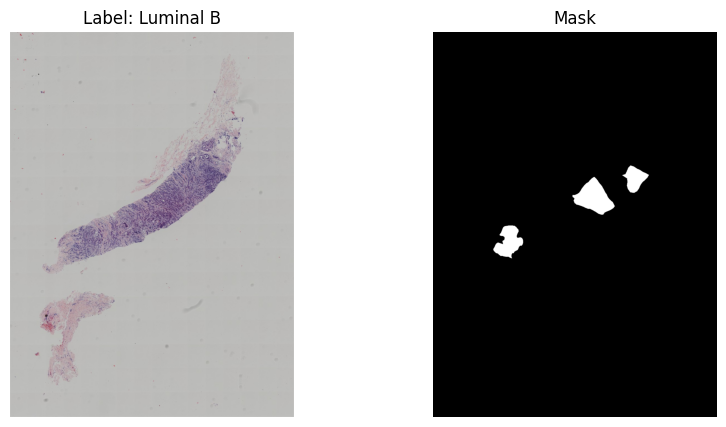

In [6]:
def show_sample(idx: int | None = None):
    if idx is None:
        idx = random.randint(0, len(train_df)-1)

    _row: pd.Series = train_df.iloc[idx]

    _img: np.ndarray = np.array(Image.open(_row["image_path"]))
    _mask: np.ndarray = np.array(Image.open(_row["mask_path"]))

    plt.figure(figsize=(10,5))
    plt.subplot(1,2,1)
    plt.title(f"Label: {_row['label']}")
    plt.imshow(_img)
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.title("Mask")
    plt.imshow(_mask, cmap="gray")
    plt.axis("off")

    plt.show()

show_sample()

### Descriptive Statistics

This part provides descriptive statistics for the newly added columns in the training DataFrame, giving insights into the distribution of image dimensions, mask pixel counts, and bounding box areas.

#### Image Dimensions

The statistics indicate that the images vary significantly in size, with widths ranging from 1024 to 3914 pixels and heights from 1024 to 4233 pixels. The mean dimensions are approximately 1218x1347 pixels. The standard deviation values suggest a wide spread in image sizes. Additionally, the number of mask pixels and bounding box areas also show considerable variation, reflecting the diversity in the dataset.

In [7]:
train_df[['width','height']].describe()

,width,height
count,581.000000,581.000000
mean,1218.860585,1347.304647
std,405.430571,518.200399
min,1024.000000,1024.000000
25%,1024.000000,1024.000000
50%,1024.000000,1097.000000
75%,1259.000000,1481.000000
max,3914.000000,4233.000000


#### Mask Pixels

The statistics for `mask_pixels` show a wide range in the number of pixels covered by the masks, with a mean of approximately 24,384 pixels and a maximum of 280,030 pixels. This indicates significant variability in the size of the regions of interest across different samples. Additionally, the standard deviation is quite high, suggesting that some masks are much larger than others.

Finally, the quartile values indicate that 25% of the samples have masks with fewer than 8,606 pixels, while 75% have masks with fewer than 28,404 pixels, highlighting the skewed distribution of mask sizes in the dataset.


In [8]:
train_df['mask_pixels'].describe()

count       581.000000
mean      24384.628227
std       31254.112789
min        1501.000000
25%        8606.000000
50%       14747.000000
75%       28404.000000
max      280030.000000
Name: mask_pixels, dtype: float64

#### Bounding Box Area

The statistics for `bbox_area` indicate a wide range of bounding box sizes around the masks, with a mean area of approximately 328k square pixels and a maximum area of 1m square pixels. This suggests significant variability in the size of the regions of interest across different samples. The standard deviation is also quite high, indicating that some bounding boxes are much larger than others. Additionally, the quartile values show that 25% of the samples have bounding box areas smaller than 154k square pixels, while 75% have areas smaller than 447k square pixels, highlighting the skewed distribution of bounding box sizes in the dataset.

Finally, the minimum bounding box area is 7,268 square pixels, indicating that even the smallest regions of interest are relatively substantial.

In [9]:
train_df['bbox_area'].describe()

count    5.810000e+02
mean     3.283599e+05
std      2.219504e+05
min      7.268000e+03
25%      1.546980e+05
50%      2.967150e+05
75%      4.477150e+05
max      1.442554e+06
Name: bbox_area, dtype: float64